# 5. Results and Demonstration

This notebook presents the empirical analysis of curriculum–labour market alignment
based on the ESCOX extraction output. The analysis follows a similar structure as the thesis so it is easier to follow.

In [1]:
# Setup and data loading

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", None)

BASE_DIR = Path("..")
OUT_DIR = BASE_DIR / "out"
DATA_DIR = BASE_DIR / "data" / "ESCO_skills" / "Original_ESCO_docs"

XLSX_PATH = OUT_DIR / "pipeline_dataset.xlsx"
SKILLGROUP_FILE = DATA_DIR / "skillGroups_en.csv"
REL_FILE = DATA_DIR / "broaderRelationsSkillPillar_en.csv"

# Load pipeline outputs
df_all = pd.read_excel(XLSX_PATH, sheet_name="skills_long_enriched_all", engine="openpyxl")
df_allowed = pd.read_excel(XLSX_PATH, sheet_name="skills_long_enriched_allowed", engine="openpyxl")

print(f"All extracted rows: {len(df_all):,}")
print(f"Allowed extracted rows: {len(df_allowed):,}")

All extracted rows: 7,202
Allowed extracted rows: 4,095


### Data preparation 
To avoid double counting, skill prevalence is measured at the level of unique records.
A skill is therefore counted at most once per job advertisement or per module.

In [2]:
# Prepare de-duplicated skill tables for analysis

core = (
    df_allowed[["source", "record_id", "skill_uri", "skill_label"]]
    .dropna(subset=["source", "record_id", "skill_uri"])
    .drop_duplicates(subset=["source", "record_id", "skill_uri"])
    .copy()
)

job = core[core["source"] == "job"][["record_id", "skill_uri", "skill_label"]].copy()
mod = core[core["source"] == "module"][["record_id", "skill_uri", "skill_label"]].copy()

n_jobs = job["record_id"].nunique()
n_mods = mod["record_id"].nunique()

print(f"Unique job advertisements: {n_jobs:,}")
print(f"Unique modules: {n_mods:,}")

Unique job advertisements: 645
Unique modules: 42


In [3]:
# Prepare module table with skill type for knowledge/competence split

mod_with_type = (
    df_allowed[df_allowed["source"] == "module"][
        ["record_id", "skill_uri", "skill_label", "skill_type"]
    ]
    .dropna(subset=["record_id", "skill_uri"])
    .drop_duplicates(subset=["record_id", "skill_uri"])
    .copy()
)

### Sanity check: Modules without skills extracted

In [4]:
# Identify modules excluded from the final skill alignment analysis

modules_meta = pd.read_excel(
    BASE_DIR / "data" / "modules.xlsx",
    engine="openpyxl"
)

all_input_modules = set(modules_meta["module_id"].dropna().astype(str).unique())
used_modules = set(mod["record_id"].dropna().astype(str).unique())

excluded_modules = sorted(all_input_modules - used_modules)

excluded_module_table = (
    modules_meta[modules_meta["module_id"].astype(str).isin(excluded_modules)]
    .copy()
)

print(f"Modules in original input: {len(all_input_modules)}")
print(f"Modules used in final analysis: {len(used_modules)}")
print(f"Modules excluded from final analysis: {len(excluded_modules)}")

display(excluded_module_table)

Modules in original input: 50
Modules used in final analysis: 42
Modules excluded from final analysis: 8


,module_id,module_title_and_learning_outcomes,module_title,learning_outcomes,mandatory
23,DLBDSEDA2,Project: Data Analysis\n▪ formulate and implement a real-world analytical use case.\n▪ analyze the suitability of different possible approaches with respect to the project task.\n▪ transfer acquired specialized analytical knowledge to real-world use cases.\n▪ derive relevant design choices from the given project setting.\n▪ make apposite choices with respect to implementation alternatives.\n▪ select appropriate resources,Project: Data Analysis,▪ formulate and implement a real-world analytical use case.\n▪ analyze the suitability of different possible approaches with respect to the project task.\n▪ transfer acquired specialized analytical knowledge to real-world use cases.\n▪ derive relevant design choices from the given project setting.\n▪ make apposite choices with respect to implementation alternatives.\n▪ select appropriate resources,No
25,DLBDSEAIS2,Project: Artificial Intelligence\n▪ determine the requirements for building an artificial intelligence system.\n▪ evaluate an application for an AI system.\n▪ transfer theoretically-sound and practically-proven methods and tools to an application\ndomain.\n▪ create an AI system for a chosen application.,Project: Artificial Intelligence,▪ determine the requirements for building an artificial intelligence system.\n▪ evaluate an application for an AI system.\n▪ transfer theoretically-sound and practically-proven methods and tools to an application\ndomain.\n▪ create an AI system for a chosen application.,No
26,DLBDSTSA,Time Series Analysis\n▪ identify the fundamental concepts of time series analysis.\n▪ cite the components of time series.\n▪ create simple time series models.\n▪ analyze time series data with ARMA and Holt-Winter models.\n▪ understand advanced topics in time series analysis.,Time Series Analysis,▪ identify the fundamental concepts of time series analysis.\n▪ cite the components of time series.\n▪ create simple time series models.\n▪ analyze time series data with ARMA and Holt-Winter models.\n▪ understand advanced topics in time series analysis.,No
27,DLBPKIEKPT1_E,"Project: AI Excellence with Creative Prompting Techniques\n▪ comprehend and apply basic prompting techniques in generative AI applications.\n▪ analyze and evaluate the effectiveness of the basic prompts.\n▪ apply ethical considerations to the design and use of AI for basic prompting techniques.\n▪ design, implement, and refine effective prompts to real-world scenarios through hands-on\nexercises.\n▪ showcase creative and innovative thinking in the application of prompting techniques to\nsolve complex problems in their field of studies",Project: AI Excellence with Creative Prompting Techniques,"▪ comprehend and apply basic prompting techniques in generative AI applications.\n▪ analyze and evaluate the effectiveness of the basic prompts.\n▪ apply ethical considerations to the design and use of AI for basic prompting techniques.\n▪ design, implement, and refine effective prompts to real-world scenarios through hands-on\nexercises.\n▪ showcase creative and innovative thinking in the application of prompting techniques to\nsolve complex problems in their field of studies",No
28,DLBDSESF1,"Smart Factory\n▪ understand the term Smart Factory in the context of Industry 4.0.\n▪ be able to trace the development of automation to a fully autonomous, non-centrally\norganized production plant.\n▪ understand the basic technologies and standards used to design and operate a Smart\nFactory.\n▪ understand the essential concepts of a Smart Factory.\n▪ identify and differentiate between the individual elements of a Smart Factory using different\nreference architectures.\n▪ understand the special engineering challenges in the Smart Energy context.\n▪ understand the special safety risks of digitized and networked production plants and assign\nconcrete recommendations for action.",Smart Factory,"▪ understand the term Smart Factory

### Sanity check: Excluded skills due to allowed skill list (ISCO restriction)
Before interpreting the alignment results, it is useful to inspect which extracted skills
were excluded by the occupation-based allowed-skill filter. This serves as a plausibility
check for the restriction to ESCO occupations associated with ICT professionals and
mathematical/statistical professionals.

In [5]:
# Top excluded skills after applying the allowed-skill restriction

top_excluded = (
    df_all[df_all["in_allowed"] == False]   # noqa: E712
    .groupby(["skill_uri", "skill_label"], dropna=False)
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

display(top_excluded)

,skill_uri,skill_label,count
0,http://data.europa.eu/esco/skill/a472a200-d895-40ca-95e7-5c5495e3dd7c,develop pension schemes,96
1,http://data.europa.eu/esco/skill/4707da90-9cfc-46ca-8de0-38a0b7bfb137,think analytically,94
2,http://data.europa.eu/esco/skill/4812a4ea-dc55-4dc6-b9b0-4a59bba2c647,German,90
3,http://data.europa.eu/esco/skill/519e801b-3cc4-44d4-bcf1-32fdb9a77e51,personal development,49
4,http://data.europa.eu/esco/skill/15d76317-c71a-4fa2-aadc-2ecc34e627b7,communication,41
5,http://data.europa.eu/esco/skill/29fb886c-6be0-4e93-9ea1-232881f2092a,plan product management,40
6,http://data.europa.eu/esco/skill/429062f1-a958-43ea-83dd-4e1af078c156,demonstrate curiosity,40
7,http://data.europa.eu/esco/skill/001115fb-569f-4ee6-8381-c6807ef2527f,show initiative,39
8,http://data.europa.eu/esco/skill/e24377fb-020b-4430-8bed-86dd539bbf3a,gender studies,38
9,http://data.europa.eu/esco/skill/199f7919-5114-41b6-b6a5-41e0e4896ec1,assume responsibility,36


# 5.1. Skill extraction results (descriptive view)

This section describes which skills are most frequently extracted from module learning
outcomes and job advertisements. The purpose is descriptive only: it characterises the
extraction output before the actual alignment assessment.

In [6]:
# Top extracted knowledge concepts in module learning outcomes

top_module_knowledge = (
    mod_with_type[mod_with_type["skill_type"] == "knowledge"]
    .groupby("skill_label", dropna=False)
    .agg(modules=("record_id", "nunique"))
    .reset_index()
)

top_module_knowledge["module_share_pct"] = (
    top_module_knowledge["modules"] / n_mods * 100
).round(1)

top_module_knowledge = (
    top_module_knowledge.sort_values(["modules", "skill_label"], ascending=[False, True])
    .head(20)
    .reset_index(drop=True)
)

display(top_module_knowledge)

,skill_label,modules,module_share_pct
0,data engineering,4,9.5
1,data science,4,9.5
2,machine learning,4,9.5
3,NoSQL,3,7.1
4,Python (computer programming),3,7.1
5,algebra,3,7.1
6,business intelligence,3,7.1
7,data visualisation software,3,7.1
8,Agile development,2,4.8
9,Agile project management,2,4.8


In [7]:
# Top extracted skill/competence concepts in module learning outcomes

top_module_competence = (
    mod_with_type[mod_with_type["skill_type"] == "skill/competence"]
    .groupby("skill_label", dropna=False)
    .agg(modules=("record_id", "nunique"))
    .reset_index()
)

top_module_competence["module_share_pct"] = (
    top_module_competence["modules"] / n_mods * 100
).round(1)

top_module_competence = (
    top_module_competence.sort_values(["modules", "skill_label"], ascending=[False, True])
    .head(20)
    .reset_index(drop=True)
)

display(top_module_competence)

,skill_label,modules,module_share_pct
0,apply scientific methods,2,4.8
1,deliver visual presentation of data,2,4.8
2,gather data,2,4.8
3,normalise data,2,4.8
4,analyse pipeline database information,1,2.4
5,apply research ethics and scientific integrity principles in research activities,1,2.4
6,build predictive models,1,2.4
7,collect customer feedback on applications,1,2.4
8,conduct research across disciplines,1,2.4
9,create database diagrams,1,2.4


In [8]:
# Top 20 extracted skills in job advertisements

top_jobs = (
    job.groupby("skill_label", dropna=False)
    .agg(job_ads=("record_id", "nunique"))
    .reset_index()
    .sort_values("job_ads", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

display(top_jobs)

,skill_label,job_ads
0,Python (computer programming),211
1,mathematics,195
2,scientific computing,163
3,data science,159
4,data quality assessment,93
5,SQL,89
6,deliver visual presentation of data,81
7,Agile development,75
8,data analytics,71
9,develop creative ideas,57


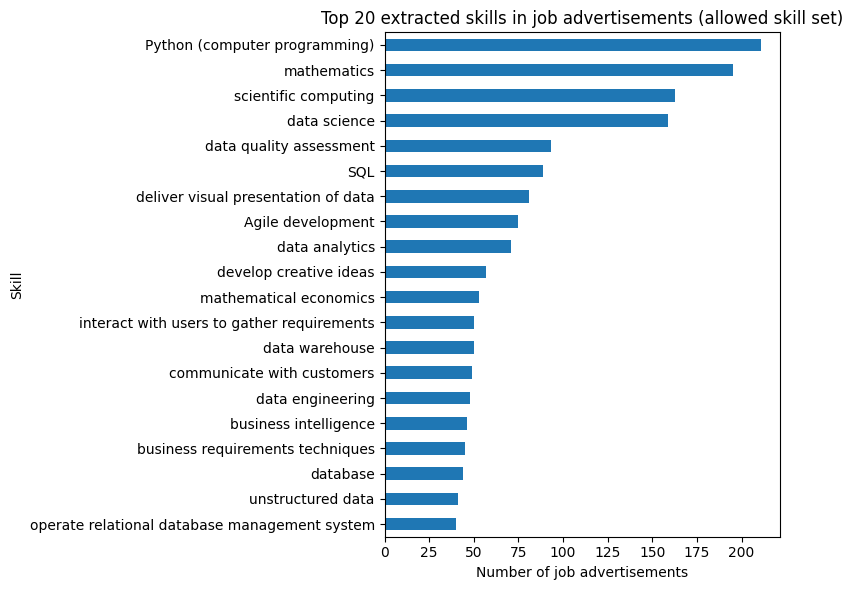

In [9]:
# Visualise the most prevalent job-market skills

ax = top_jobs.sort_values("job_ads").plot.barh(
    x="skill_label",
    y="job_ads",
    legend=False,
    figsize=(8, 6)
)

ax.set_xlabel("Number of job advertisements")
ax.set_ylabel("Skill")
ax.set_title("Top 20 extracted skills in job advertisements (allowed skill set)")
plt.tight_layout()
plt.show()

# 5.2 ESCO matching results

Core alignment analysis at skill level: The main analysis compares skill prevalence in job advertisements with skill prevalence
in module learning outcomes. A job-market skill is considered covered if the same
`skill_uri` appears in at least one module.

Three result tables are produced:
1. Coverage headline metrics
2. Top covered skills by job prevalence
3. Top missing skills by job prevalence

In [10]:
# Prevalence per skill in jobs and modules

job_counts = (
    job.groupby(["skill_uri", "skill_label"], dropna=False)
    .agg(job_ads=("record_id", "nunique"))
    .reset_index()
)

mod_counts = (
    mod.groupby("skill_uri", dropna=False)
    .agg(modules=("record_id", "nunique"))
    .reset_index()
)

cmp = job_counts.merge(mod_counts, on="skill_uri", how="left")
cmp["modules"] = cmp["modules"].fillna(0).astype(int)
cmp["covered"] = cmp["modules"] > 0

cmp["job_share_pct"] = (cmp["job_ads"] / n_jobs * 100).round(1)
cmp["module_share_pct"] = (cmp["modules"] / n_mods * 100).round(1)

In [11]:

# Coverage headline metrics

unique_job_skills = int(cmp["skill_uri"].nunique())
unique_module_skills = int(mod["skill_uri"].nunique())
unique_overlap_skills = int(cmp.loc[cmp["covered"], "skill_uri"].nunique())

total_job_skill_demand = int(cmp["job_ads"].sum())
covered_job_skill_demand = int(cmp.loc[cmp["covered"], "job_ads"].sum())
coverage_demand_weighted = covered_job_skill_demand / total_job_skill_demand if total_job_skill_demand else 0.0

headline = pd.DataFrame([{
    "job_ads_unique": n_jobs,
    "modules_unique": n_mods,
    "unique_job_skills": unique_job_skills,
    "unique_module_skills": unique_module_skills,
    "unique_overlap_skills": unique_overlap_skills,
    "unique_overlap_pct_of_job_skills": round(unique_overlap_skills / unique_job_skills * 100, 1) if unique_job_skills else 0.0,
    "total_job_skill_demand": total_job_skill_demand,
    "covered_job_skill_demand": covered_job_skill_demand,
    "coverage_demand_weighted_pct": round(coverage_demand_weighted * 100, 1),
}])

display(headline)

,job_ads_unique,modules_unique,unique_job_skills,unique_module_skills,unique_overlap_skills,unique_overlap_pct_of_job_skills,total_job_skill_demand,covered_job_skill_demand,coverage_demand_weighted_pct
0,645,42,344,73,62,18.0,3986,1844,46.3


In [12]:
# Top covered skills by job prevalence

TOP_N = 30

top_covered = (
    cmp[cmp["covered"]]
    .sort_values(["job_ads", "job_share_pct", "modules"], ascending=False)
    .head(TOP_N)
    .reset_index(drop=True)
    [["skill_label", "job_ads", "job_share_pct", "modules", "module_share_pct", "skill_uri"]]
)

display(top_covered)

,skill_label,job_ads,job_share_pct,modules,module_share_pct,skill_uri
0,Python (computer programming),211,32.7,3,7.1,http://data.europa.eu/esco/skill/ccd0a1d9-afda-43d9-b901-96344886e14d
1,mathematics,195,30.2,2,4.8,http://data.europa.eu/esco/skill/4339176e-3acd-4f7f-a5d9-445bee3d23f2
2,data science,159,24.7,4,9.5,http://data.europa.eu/esco/skill/edebd83d-35f6-4ed5-a940-6c203d178c01
3,data quality assessment,93,14.4,2,4.8,http://data.europa.eu/esco/skill/cc7370dd-69fa-4c67-a96f-d4d135d38700
4,SQL,89,13.8,2,4.8,http://data.europa.eu/esco/skill/598de5b0-5b58-4ea7-8058-a4bc4d18c742
5,deliver visual presentation of data,81,12.6,2,4.8,http://data.europa.eu/esco/skill/c3e36d05-8ae8-447f-bb2b-6f9409f85389
6,Agile development,75,11.6,2,4.8,http://data.europa.eu/esco/skill/dba46f87-0831-49cd-a1c7-340a653c0221
7,data analytics,71,11.0,2,4.8,http://data.europa.eu/esco/skill/97bd1c21-66b2-4b7e-ad0f-e3cda590e378
8,data warehouse,50,7.8,1,2.4,http://data.europa.eu/esco/skill/3ec2e4d6-7000-4905-bf1a-c5b1679416de
9,interact with users to gather requirements,50,7.8,1,2.4,http://data.europa.eu/esco/skill/a8797f21-1af0-4c5e-98ca-bf1442929363


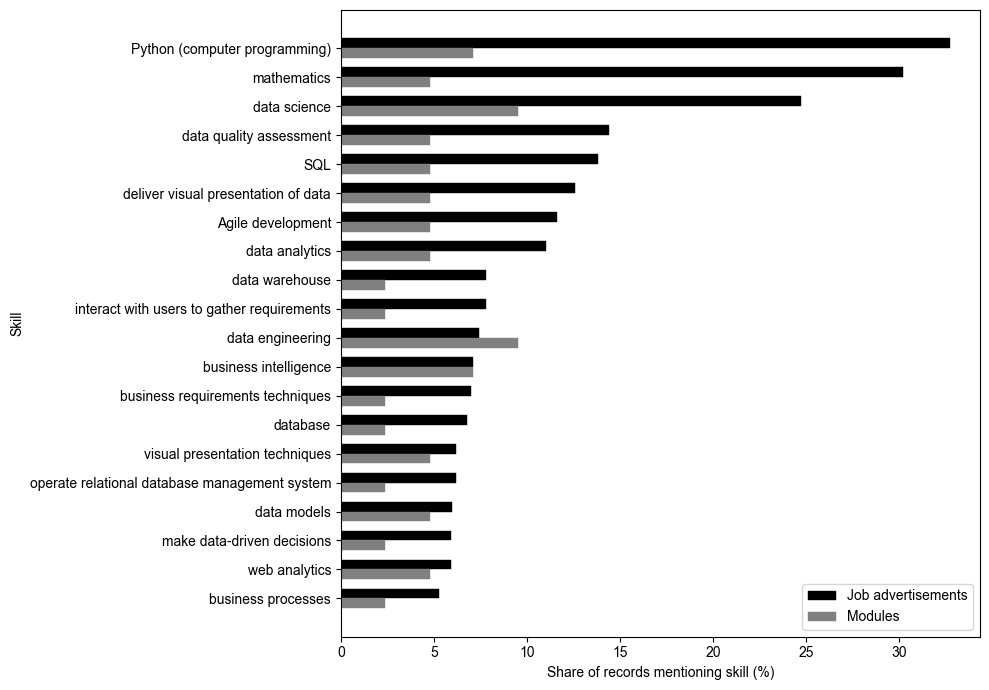

In [13]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.family"] = "Arial"

plot_df = (
    top_covered.head(20)
    .sort_values("job_share_pct", ascending=True)
    .reset_index(drop=True)
)

y = np.arange(len(plot_df))
bar_h = 0.34

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    y + bar_h/2,
    plot_df["job_share_pct"],
    height=bar_h,
    color="black",
    edgecolor="black",
    linewidth=0.3,
    label="Job advertisements"
)

ax.barh(
    y - bar_h/2,
    plot_df["module_share_pct"],
    height=bar_h,
    color="grey",
    edgecolor="grey",
    linewidth=0.3,
    label="Modules"
)

ax.set_yticks(y)
ax.set_yticklabels(plot_df["skill_label"])
ax.set_xlabel("Share of records mentioning skill (%)")
ax.set_ylabel("Skill")
ax.legend(frameon=True)

plt.tight_layout()
plt.show()

In [14]:
# Top missing skills by job prevalence

MIN_JOB_ADS = 10

top_missing = (
    cmp[(~cmp["covered"]) & (cmp["job_ads"] >= MIN_JOB_ADS)]
    .sort_values(["job_ads", "job_share_pct"], ascending=False)
    .head(TOP_N)
    .reset_index(drop=True)
    [["skill_label", "job_ads", "job_share_pct", "modules", "skill_uri"]]
)

display(top_missing)

,skill_label,job_ads,job_share_pct,modules,skill_uri
0,scientific computing,163,25.3,0,http://data.europa.eu/esco/skill/5b26f08b-88bc-45f0-b901-530d7786466b
1,develop creative ideas,57,8.8,0,http://data.europa.eu/esco/skill/8c4c49d4-9708-433f-8ca7-bf2c5211ee49
2,mathematical economics,53,8.2,0,http://data.europa.eu/esco/skill/2a0efd9a-4a60-4edc-8561-f2754d24eeb8
3,communicate with customers,49,7.6,0,http://data.europa.eu/esco/skill/0da516ee-e70e-4384-be13-f5ff80be8127
4,unstructured data,41,6.4,0,http://data.europa.eu/esco/skill/c5e8abde-d2ba-4e8e-a65e-720b71180666
5,apply statistical analysis techniques,40,6.2,0,http://data.europa.eu/esco/skill/382c11ed-20d5-4ae7-b60e-15fec527fa6c
6,"data extraction, transformation and loading tools",39,6.0,0,http://data.europa.eu/esco/skill/9d0d89be-bffa-4393-b6f6-8d05bea49051
7,innovation processes,36,5.6,0,http://data.europa.eu/esco/skill/2fb8480e-de3c-462b-b169-e8bbb344da68
8,communicate with stakeholders,33,5.1,0,http://data.europa.eu/esco/skill/477173ca-5fc2-406b-9122-95d92811f284
9,digitization,33,5.1,0,http://data.europa.eu/esco/skill/aa0d8201-5a8e-417f-81f4-c04601139582


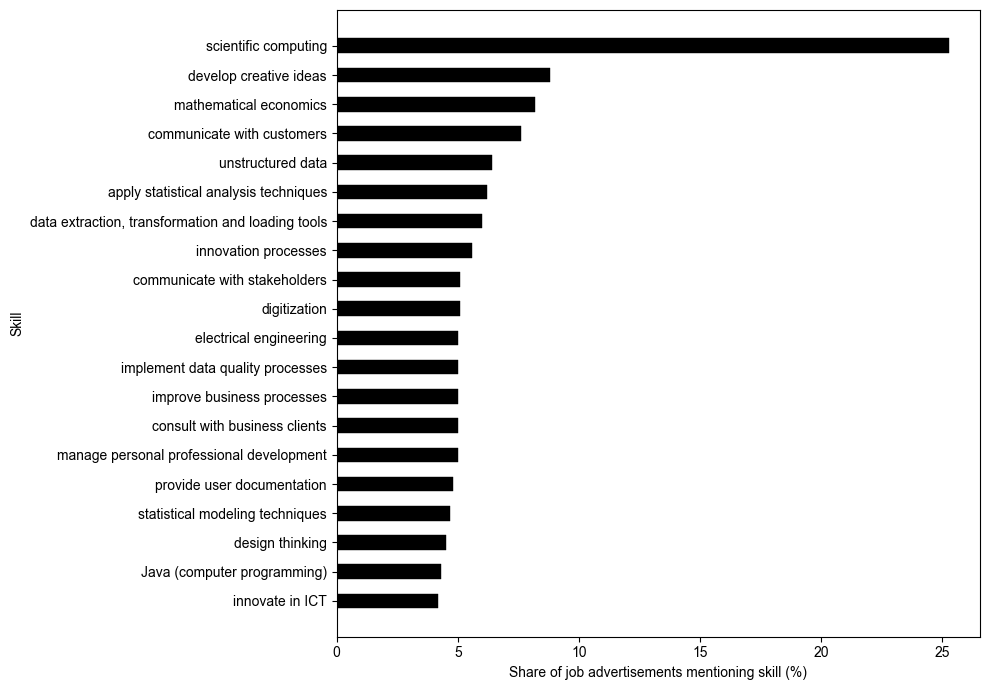

In [15]:
plt.rcParams["font.family"] = "Arial"

plot_df = (
    top_missing.head(20)
    .sort_values("job_share_pct", ascending=True)
    .reset_index(drop=True)
)

y = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    y,
    plot_df["job_share_pct"],
    height=0.5,
    color="black",
    edgecolor="black",
    linewidth=0.3
)

ax.set_yticks(y)
ax.set_yticklabels(plot_df["skill_label"])
ax.set_xlabel("Share of job advertisements mentioning skill (%)")
ax.set_ylabel("Skill")

plt.tight_layout()
plt.show()

### Interpretation aid: demand-weighted coverage

Unique overlap alone can be misleading because all skills are weighted equally.
Demand-weighted coverage therefore captures whether the curriculum covers skills
that occur frequently across job advertisements.

In [16]:
unique_overlap_pct_of_job_skills = (
    round(unique_overlap_skills / unique_job_skills * 100, 1)
    if unique_job_skills else 0.0
)

print(f"Unique overlap pct of job skills: {unique_overlap_pct_of_job_skills}%")
print(f"Demand-weighted coverage: {coverage_demand_weighted:.2%}")

Unique overlap pct of job skills: 18.0%
Demand-weighted coverage: 46.26%


Note: The raw coverage metrics should not be read as literal measures of missing
curriculum content. They are better interpreted as conservative lower-bound indicators
of alignment that still require human validation at fine-grained skill level; see later sections

### Robustness check: does the URI-level mismatch dissolve at coarser levels? ===

 Levels (all measured against the SAME demand base as the 46.3% headline):
   - URI level             : individual skill (skill_uri)            -> main analysis
   - Immediate SkillGroup   : SX.X.X (S) / NNNN (N)                  -> one step up from URI
   - Parent SkillGroup      : SX.X   (S) / NNN  (N)                  -> two steps up from URI

 Weighting: each job-side (record_id, skill_uri) mention counts ONCE, exactly as in
 the headline metric. A skill counts as covered at a SkillGroup level if at least one
 of its SkillGroups also occurs on the module side. This avoids the multi-homing
 inflation that arises when a skill maps to several SkillGroups.

In [25]:
# --- Demand base: job-side skill mentions (identical unit to the 46.3% headline) ---
job_mentions = core.loc[core["source"] == "job", ["record_id", "skill_uri"]].drop_duplicates()
mod_skills   = set(core.loc[core["source"] == "module", "skill_uri"].unique())

# --- skill_uri -> set of SkillGroup codes, per level (only skills with a valid leaf mapping) ---
job_leaf   = x_leaf[x_leaf["source"] == "job"]
mod_leaf   = x_leaf[x_leaf["source"] == "module"]

skill_to_leaf   = x_leaf.assign(code=x_leaf["code"].astype(str)).groupby("skill_uri")["code"].agg(set)
skill_to_parent = x_leaf.assign(code_parent=x_leaf["code_parent"].astype(str)).groupby("skill_uri")["code_parent"].agg(set)

mod_leaf_codes   = set(mod_leaf["code"].astype(str).unique())
mod_parent_codes = set(mod_leaf["code_parent"].astype(str).unique())


def mention_weighted_coverage(level_name, skill_to_codes, mod_covered_codes):
    """Demand-weighted coverage at a SkillGroup level, weighted by job skill mentions.

    A job mention is covered if any of its skill's SkillGroups is covered module-side.
    The base is restricted to job mentions whose skill has a valid mapping at this level,
    so the figure is comparable across levels (and reported alongside that base size).
    """
    m = job_mentions.copy()
    m["codes"] = m["skill_uri"].map(skill_to_codes)
    m = m[m["codes"].notna()]                       # keep only mappable mentions
    base = len(m)
    covered_mask = m["codes"].apply(lambda s: len(s & mod_covered_codes) > 0)
    covered = int(covered_mask.sum())
    coverage = covered / base if base else 0.0
    return {
        "level": level_name,
        "coverage_demand_weighted_pct": round(coverage * 100, 1),
        "covered_mentions": covered,
        "base_mentions": base,
    }


# --- URI-level reference, recomputed on the SAME base for a like-for-like comparison ---
uri = job_mentions.copy()
uri["covered"] = uri["skill_uri"].isin(mod_skills)
uri_row = {
    "level": "URI level (skill_uri)",
    "coverage_demand_weighted_pct": round(uri["covered"].mean() * 100, 1),
    "covered_mentions": int(uri["covered"].sum()),
    "base_mentions": int(len(uri)),
}

rollup_summary = pd.DataFrame([
    uri_row,
    mention_weighted_coverage("Immediate SkillGroup (SX.X.X / NNNN)", skill_to_leaf,   mod_leaf_codes),
    mention_weighted_coverage("Parent SkillGroup (SX.X / NNN)",        skill_to_parent, mod_parent_codes),
])

display(rollup_summary)

,level,coverage_demand_weighted_pct,covered_mentions,base_mentions
0,URI level (skill_uri),46.3,1844,3986
1,Immediate SkillGroup (SX.X.X / NNNN),76.9,3020,3925
2,Parent SkillGroup (SX.X / NNN),84.0,3296,3925


In [26]:
# === Diagnostic: what does the Immediate SkillGroup level actually fold together? ===
# For the most demanded immediate SkillGroups, list the distinct skills they contain,
# so we can judge whether "covered at this level" is still substantively meaningful.

job_leaf = x_leaf[x_leaf["source"] == "job"].copy()
job_leaf["code"] = job_leaf["code"].astype(str)

# group label lookup (code -> preferredLabel of the SkillGroup)
code_to_label = (
    x_leaf.dropna(subset=["group_label"])
    .assign(code=lambda d: d["code"].astype(str))
    .drop_duplicates("code")
    .set_index("code")["group_label"]
    .to_dict()
)

# demand per immediate group (weighted by distinct job ads)
group_demand = (
    job_leaf.groupby("code")["record_id"].nunique()
    .sort_values(ascending=False)
)

# skills folded into each group, with their own job-ad demand
skill_demand = (
    core[core["source"] == "job"]
    .groupby("skill_uri")["record_id"].nunique()
)
uri_to_label = (
    core.dropna(subset=["skill_label"])
    .drop_duplicates("skill_uri")
    .set_index("skill_uri")["skill_label"].to_dict()
)

for code in group_demand.head(10).index:
    skills = sorted(
        job_leaf.loc[job_leaf["code"] == code, "skill_uri"].unique(),
        key=lambda u: skill_demand.get(u, 0), reverse=True
    )
    covered = code in mod_leaf_codes
    print(f"\n[{code}] {code_to_label.get(code, '?')}  "
          f"| job-ad demand={group_demand[code]} | covered module-side={covered} "
          f"| {len(skills)} distinct skills folded in")
    for u in skills[:8]:
        print(f"    {skill_demand.get(u, 0):>4}  {uri_to_label.get(u, u)}")


[0613] software and applications development and analysis  | job-ad demand=359 | covered module-side=True | 44 distinct skills folded in
     211  Python (computer programming)
      89  SQL
      75  Agile development
      28  Java (computer programming)
      27  MATLAB
      23  computer programming
      22  DevOps
      20  Scala

[0612] database and network design and administration  | job-ad demand=337 | covered module-side=True | 35 distinct skills folded in
      71  data analytics
      50  data warehouse
      44  database
      41  unstructured data
      39  data models
      39  data extraction, transformation and loading tools
      38  web analytics
      30  data visualisation software

[0688] inter-disciplinary programmes and qualifications involving information and communication technologies (icts)  | job-ad demand=293 | covered module-side=True | 3 distinct skills folded in
     163  scientific computing
     159  data science
       4  digital systems

[0541] mat

In [27]:
g = "0613"
skills_in_group = sorted(
    job_leaf.loc[job_leaf["code"] == g, "skill_uri"].unique(),
    key=lambda u: skill_demand.get(u, 0), reverse=True
)
mod_skill_set = set(core.loc[core["source"] == "module", "skill_uri"].unique())

print("COVERED module-side (real):")
for u in skills_in_group:
    if u in mod_skill_set:
        print(f"  {skill_demand.get(u,0):>4}  {uri_to_label.get(u,u)}")

print("\nNOT covered module-side (credited only by roll-up):")
for u in skills_in_group:
    if u not in mod_skill_set:
        print(f"  {skill_demand.get(u,0):>4}  {uri_to_label.get(u,u)}")

COVERED module-side (real):
   211  Python (computer programming)
    89  SQL
    75  Agile development
    23  computer programming
    15  Hadoop
     7  Prototyping development
     5  software design methodologies
     2  software frameworks
     2  systems development life-cycle

NOT covered module-side (credited only by roll-up):
    28  Java (computer programming)
    27  MATLAB
    22  DevOps
    20  Scala
    20  SAS language
    15  SPARK
    14  R
    13  C++
    13  computer science
    10  Rapid application development
     8  Jenkins (tools for software configuration management)
     6  ML (computer programming)
     6  system design
     6  web services
     5  TypeScript
     5  tools for software configuration management
     5  operating systems
     4  Angular
     4  C#
     4  iterative development
     3  digital twin technology
     3  software components suppliers
     3  Android (mobile operating systems)
     2  ABAP
     2  query languages
     2  Visual Basi

--> even a single step up from the URI already aggregates across genuinely distinct skills, so coverage at that level answers a question no longer connected to curricular alignment!

## Manual review of the most prevalent uncovered skills

To improve interpretive validity, the most prevalent uncovered skills are manually reviewed and classified into likely true gaps, likely matching artefacts, likely irrelevant noise, or ambiguous cases.

In [19]:
# Purpose:
# Create a structured review table for the top uncovered job-market skills so that
# automated "missing" signals can be interpreted more carefully.

REVIEW_N = 30  # number of uncovered skills to review manually

manual_review = (
    top_missing.head(REVIEW_N)
    .copy()
    .assign(
        manual_classification="",
        short_rationale=""
    )
)

display(manual_review)

,skill_label,job_ads,job_share_pct,modules,skill_uri,manual_classification,short_rationale
0,scientific computing,163,25.3,0,http://data.europa.eu/esco/skill/5b26f08b-88bc-45f0-b901-530d7786466b,,
1,develop creative ideas,57,8.8,0,http://data.europa.eu/esco/skill/8c4c49d4-9708-433f-8ca7-bf2c5211ee49,,
2,mathematical economics,53,8.2,0,http://data.europa.eu/esco/skill/2a0efd9a-4a60-4edc-8561-f2754d24eeb8,,
3,communicate with customers,49,7.6,0,http://data.europa.eu/esco/skill/0da516ee-e70e-4384-be13-f5ff80be8127,,
4,unstructured data,41,6.4,0,http://data.europa.eu/esco/skill/c5e8abde-d2ba-4e8e-a65e-720b71180666,,
5,apply statistical analysis techniques,40,6.2,0,http://data.europa.eu/esco/skill/382c11ed-20d5-4ae7-b60e-15fec527fa6c,,
6,"data extraction, transformation and loading tools",39,6.0,0,http://data.europa.eu/esco/skill/9d0d89be-bffa-4393-b6f6-8d05bea49051,,
7,innovation processes,36,5.6,0,http://data.europa.eu/esco/skill/2fb8480e-de3c-462b-b169-e8bbb344da68,,
8,communicate with stakeholders,33,5.1,0,http://data.europa.eu/esco/skill/477173ca-5fc2-406b-9122-95d92811f284,,
9,digitization,33,5.1,0,http://data.europa.eu/esco/skill/aa0d8201-5a8e-417f-81f4-c04601139582,,


Manual review rules:

Is the skill clearly irrelevant to a data science curriculum?
→ domain-irrelevant

Is the skill obviously too broad / generic to support a meaningful curricular claim?
→ too generic

Is there clear evidence that the substance is already in the curriculum under other wording?
→ covered but not matched

Is the skill a specific tool demand (e.g. SAP Data Service)?
→ tool-specific

If not, does it look like a plausible labour-market-relevant omission?
→ true gap


The results of the manual review are hardcoded below so that the results can also be seen here in this notebook:

In [20]:
# %%
# Hardcoded manual review labels for the 30 most prevalent uncovered skills

manual_labels = {
    "scientific computing": {
        "manual_classification": "covered but not matched",
        "short_rationale": "Basically covered across programming and quantitative modules, just not under this label."
    },
    "develop creative ideas": {
        "manual_classification": "covered but not matched",
        "short_rationale": "Creative and innovative thinking is explicitly mentioned in the prompting project module."
    },
    "mathematical economics": {
        "manual_classification": "covered but not matched",
        "short_rationale": "Managerial Economics is in the curriculum, just not with this wording."
    },
    "communicate with customers": {
        "manual_classification": "covered but not matched",
        "short_rationale": "Sales modules clearly cover customer communication and CRM-related topics."
    },
    "unstructured data": {
        "manual_classification": "covered but not matched",
        "short_rationale": "Likely covered through NLP/AI-related content, but not named like this."
    },
    "apply statistical analysis techniques": {
        "manual_classification": "covered but not matched",
        "short_rationale": "Clearly covered in the statistics and analysis modules."
    },
    "data extraction, transformation and loading tools": {
        "manual_classification": "covered but not matched",
        "short_rationale": "Data engineering and wrangling content covers this in substance."
    },
    "innovation processes": {
        "manual_classification": "too generic",
        "short_rationale": "Too broad to say much about curriculum fit."
    },
    "communicate with stakeholders": {
        "manual_classification": "covered but not matched",
        "short_rationale": "Collaboration and project modules cover stakeholder communication in substance."
    },
    "digitization": {
        "manual_classification": "too generic",
        "short_rationale": "Too vague to be useful here."
    },
    "electrical engineering": {
        "manual_classification": "domain-irrelevant",
        "short_rationale": "Not a relevant target for a general data science curriculum."
    },
    "implement data quality processes": {
        "manual_classification": "covered but not matched",
        "short_rationale": "Data quality is explicitly covered in the wrangling/data quality module."
    },
    "improve business processes": {
        "manual_classification": "too generic",
        "short_rationale": "Too broad and business-generic to interpret strongly."
    },
    "consult with business clients": {
        "manual_classification": "covered but not matched",
        "short_rationale": "Sales and marketing modules overlap with this quite clearly."
    },
    "manage personal professional development": {
        "manual_classification": "too generic",
        "short_rationale": "Generic employability skill, not really data-science-specific."
    },
    "provide user documentation": {
        "manual_classification": "covered but not matched",
        "short_rationale": "Documentation is explicitly part of the BI project module."
    },
    "statistical modeling techniques": {
        "manual_classification": "covered but not matched",
        "short_rationale": "Covered through statistics, modelling, and time series content."
    },
    "design thinking": {
        "manual_classification": "true gap",
        "short_rationale": "Not clearly visible in the learning outcomes, unlike the other applied skills."
    },
    "Java (computer programming)": {
        "manual_classification": "tool-specific",
        "short_rationale": "Specific language demand, not a separate core competence."
    },
    "innovate in ICT": {
        "manual_classification": "too generic",
        "short_rationale": "Too broad to support a meaningful curriculum claim."
    },
    "MATLAB": {
        "manual_classification": "tool-specific",
        "short_rationale": "Tool-specific demand rather than a distinct missing competence."
    },
    "SAP Data Services": {
        "manual_classification": "tool-specific",
        "short_rationale": "Specific enterprise tool, not something a DS curriculum must teach directly."
    },
    "create data models": {
        "manual_classification": "covered but not matched",
        "short_rationale": "Database modelling is explicitly covered in the curriculum."
    },
    "utilise machine learning": {
        "manual_classification": "covered but not matched",
        "short_rationale": "Clearly covered through the ML modules."
    },
    "data mining": {
        "manual_classification": "covered but not matched",
        "short_rationale": "Substantively overlaps with data analysis and ML content."
    },
    "use presentation software": {
        "manual_classification": "too generic",
        "short_rationale": "Generic office skill, not very informative here."
    },
    "perform project management": {
        "manual_classification": "covered but not matched",
        "short_rationale": "Explicitly covered through the Agile Project Management module."
    },
    "DevOps": {
        "manual_classification": "covered but not matched",
        "short_rationale": "Related content is there, even if the exact term is not used."
    },
    "monitor developments in field of expertise": {
        "manual_classification": "too generic",
        "short_rationale": "Very broad lifelong-learning skill, not very useful analytically."
    },
    "SAS language": {
        "manual_classification": "tool-specific",
        "short_rationale": "Software-specific preference, not a separate analytical competence."
    },
}

manual_review = manual_review.reset_index(drop=True)
manual_review["id"] = manual_review.index

manual_review["manual_classification"] = manual_review["skill_label"].map(
    lambda x: manual_labels.get(x, {}).get("manual_classification", "")
)

manual_review["short_rationale"] = manual_review["skill_label"].map(
    lambda x: manual_labels.get(x, {}).get("short_rationale", "")
)

display(
    manual_review[["id", "skill_label", "manual_classification", "short_rationale"]]
)

,id,skill_label,manual_classification,short_rationale
0,0,scientific computing,covered but not matched,"Basically covered across programming and quantitative modules, just not under this label."
1,1,develop creative ideas,covered but not matched,Creative and innovative thinking is explicitly mentioned in the prompting project module.
2,2,mathematical economics,covered but not matched,"Managerial Economics is in the curriculum, just not with this wording."
3,3,communicate with customers,covered but not matched,Sales modules clearly cover customer communication and CRM-related topics.
4,4,unstructured data,covered but not matched,"Likely covered through NLP/AI-related content, but not named like this."
5,5,apply statistical analysis techniques,covered but not matched,Clearly covered in the statistics and analysis modules.
6,6,"data extraction, transformation and loading tools",covered but not matched,Data engineering and wrangling content covers this in substance.
7,7,innovation processes,too generic,Too broad to say much about curriculum fit.
8,8,communicate with stakeholders,covered but not matched,Collaboration and project modules cover stakeholder communication in substance.
9,9,digitization,too generic,Too vague to be useful here.


In [21]:
# Summary of manual review classifications

review_summary = (
    manual_review["manual_classification"]
    .value_counts(dropna=False)
    .rename_axis("manual_classification")
    .reset_index(name="n_skills")
)

review_summary["pct_of_reviewed_skills"] = (
    review_summary["n_skills"] / review_summary["n_skills"].sum() * 100
).round(1)

display(review_summary)

# Core headline numbers
n_reviewed = len(manual_review)
n_true_gaps = (manual_review["manual_classification"] == "true gap").sum()
n_covered_not_matched = (manual_review["manual_classification"] == "covered but not matched").sum()
n_too_generic = (manual_review["manual_classification"] == "too generic").sum()
n_tool_specific = (manual_review["manual_classification"] == "tool-specific").sum()
n_domain_irrelevant = (manual_review["manual_classification"] == "domain-irrelevant").sum()

print(f"Reviewed uncovered skills: {n_reviewed}")
print(f"Plausible true gaps: {n_true_gaps} ({n_true_gaps / n_reviewed:.1%})")
print(f"Covered but not matched: {n_covered_not_matched} ({n_covered_not_matched / n_reviewed:.1%})")
print(f"Too generic: {n_too_generic} ({n_too_generic / n_reviewed:.1%})")
print(f"Tool-specific: {n_tool_specific} ({n_tool_specific / n_reviewed:.1%})")
print(f"Domain-irrelevant: {n_domain_irrelevant} ({n_domain_irrelevant / n_reviewed:.1%})")

,manual_classification,n_skills,pct_of_reviewed_skills
0,covered but not matched,17,56.7
1,too generic,7,23.3
2,tool-specific,4,13.3
3,domain-irrelevant,1,3.3
4,true gap,1,3.3


Reviewed uncovered skills: 30
Plausible true gaps: 1 (3.3%)
Covered but not matched: 17 (56.7%)
Too generic: 7 (23.3%)
Tool-specific: 4 (13.3%)
Domain-irrelevant: 1 (3.3%)


In [22]:
# Demand-weighted summary of manual review classifications
# This shows how much of the uncovered job-skill demand falls into each category.

review_demand_summary = (
    manual_review.groupby("manual_classification", dropna=False)
    .agg(
        n_skills=("skill_label", "count"),
        total_job_ads=("job_ads", "sum")
    )
    .reset_index()
    .sort_values("total_job_ads", ascending=False)
)

review_demand_summary["pct_of_reviewed_demand"] = (
    review_demand_summary["total_job_ads"] / review_demand_summary["total_job_ads"].sum() * 100
).round(1)

display(review_demand_summary)

true_gap_demand = manual_review.loc[
    manual_review["manual_classification"] == "true gap", "job_ads"
].sum()

print(
    f"Job-skill demand linked to plausible true gaps: "
    f"{true_gap_demand} mentions "
    f"({true_gap_demand / manual_review['job_ads'].sum():.1%} of reviewed uncovered demand)"
)

,manual_classification,n_skills,total_job_ads,pct_of_reviewed_demand
0,covered but not matched,17,720,66.3
2,too generic,7,203,18.7
3,tool-specific,4,102,9.4
1,domain-irrelevant,1,32,2.9
4,true gap,1,29,2.7


Job-skill demand linked to plausible true gaps: 29 mentions (2.7% of reviewed uncovered demand)


### Interpretation of the raw coverage metrics
The raw automated results show a unique overlap of 18.0% and a demand-weighted
coverage of 46.26%. However, these values refer only to overlap in the ESCOX-extracted
skill representation of module learning outcomes.

The manual review shows that most of the apparent non-coverage is not a plausible
curriculum gap. Among the 30 most prevalent uncovered skills, 56.7% were judged to be
covered in substance but not matched, whereas only 3.3% were judged to be plausible
true gaps. Demand-weighted, only 2.7% of the reviewed uncovered demand was linked to
a plausible true gap.



--

## Additional analyses

### Mandatory modules only vs full curriculum (all optional ones)

In [23]:
# %%
# Gap comparison: mandatory modules only vs full curriculum
# Goal:
# Show which job-market skills are uncovered in
# (a) mandatory modules only
# (b) full curriculum
# and how this changes the interpretation of apparent gaps.

TOP_N = 30
MIN_JOB_ADS = 10

def compute_gap_table_for_module_subset(
    mod_subset: pd.DataFrame,
    scenario_name: str,
    top_n: int = TOP_N,
    min_job_ads: int = MIN_JOB_ADS,
) -> pd.DataFrame:
    mod_counts = (
        mod_subset.groupby("skill_uri", dropna=False)
        .agg(modules=("record_id", "nunique"))
        .reset_index()
    )

    cmp = job_counts.merge(mod_counts, on="skill_uri", how="left")
    cmp["modules"] = cmp["modules"].fillna(0).astype(int)
    cmp["covered"] = cmp["modules"] > 0

    gap_table = (
        cmp[(~cmp["covered"]) & (cmp["job_ads"] >= min_job_ads)]
        .sort_values(["job_ads", "job_share_pct"], ascending=False)
        .head(top_n)
        .reset_index(drop=True)
        .copy()
    )

    gap_table["scenario"] = scenario_name

    return gap_table[
        ["scenario", "skill_label", "job_ads", "job_share_pct", "modules", "skill_uri"]
    ]


# Recreate cmp with shares if not already present
job_counts = (
    job.groupby(["skill_uri", "skill_label"], dropna=False)
    .agg(job_ads=("record_id", "nunique"))
    .reset_index()
)
job_counts["job_share_pct"] = (job_counts["job_ads"] / n_jobs * 100).round(1)

# Gap tables by scenario
top_missing_mandatory = compute_gap_table_for_module_subset(
    mod_mandatory,
    "Mandatory modules only"
)

top_missing_full = compute_gap_table_for_module_subset(
    mod_full,
    "Full curriculum"
)

display(top_missing_mandatory)
display(top_missing_full)

NameError: name 'mod_mandatory' is not defined

In [ ]:
# %%
# Gap comparison: mandatory modules only vs full curriculum
# Self-contained version

from pathlib import Path
import pandas as pd

TOP_N = 30
MIN_JOB_ADS = 10

# --- Load module metadata (mandatory flag) ---
modules_meta = pd.read_excel(
    Path("..") / "data" / "modules.xlsx",
    engine="openpyxl"
)

module_flags = (
    modules_meta[["module_id", "mandatory"]]
    .dropna(subset=["module_id"])
    .drop_duplicates(subset=["module_id"])
    .rename(columns={"module_id": "record_id"})
    .copy()
)

# --- Load base skill table ---
try:
    _df = df.copy()  # if already loaded in notebook
except NameError:
    _df = pd.read_excel(
        Path("..") / "out" / "pipeline_dataset.xlsx",
        sheet_name="skills_long_enriched_allowed",
        engine="openpyxl"
    )

core = (
    _df[["source", "record_id", "skill_uri", "skill_label"]]
    .dropna(subset=["source", "record_id", "skill_uri"])
    .drop_duplicates(subset=["source", "record_id", "skill_uri"])
    .copy()
)

job = core[core["source"] == "job"][["record_id", "skill_uri", "skill_label"]].copy()
mod_all = core[core["source"] == "module"][["record_id", "skill_uri"]].copy()

# --- Attach mandatory flag ---
mod_all = mod_all.merge(module_flags, on="record_id", how="left")

mod_all["mandatory_norm"] = (
    mod_all["mandatory"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# --- Define subsets ---
mod_mandatory = mod_all[mod_all["mandatory_norm"] == "yes"].copy()
mod_full = mod_all.copy()

# --- Build job counts ---
n_jobs = job["record_id"].nunique()

job_counts = (
    job.groupby(["skill_uri", "skill_label"], dropna=False)
    .agg(job_ads=("record_id", "nunique"))
    .reset_index()
)

job_counts["job_share_pct"] = (job_counts["job_ads"] / n_jobs * 100).round(1)

# --- Function for gap table ---
def compute_gap_table_for_module_subset(
    mod_subset: pd.DataFrame,
    scenario_name: str,
    top_n: int = TOP_N,
    min_job_ads: int = MIN_JOB_ADS,
) -> pd.DataFrame:
    mod_counts = (
        mod_subset.groupby("skill_uri", dropna=False)
        .agg(modules=("record_id", "nunique"))
        .reset_index()
    )

    cmp = job_counts.merge(mod_counts, on="skill_uri", how="left")
    cmp["modules"] = cmp["modules"].fillna(0).astype(int)
    cmp["covered"] = cmp["modules"] > 0

    gap_table = (
        cmp[(~cmp["covered"]) & (cmp["job_ads"] >= min_job_ads)]
        .sort_values(["job_ads", "job_share_pct"], ascending=False)
        .head(top_n)
        .reset_index(drop=True)
        .copy()
    )

    gap_table["scenario"] = scenario_name

    return gap_table[
        ["scenario", "skill_label", "job_ads", "job_share_pct", "modules", "skill_uri"]
    ]

# --- Compute gap tables ---
top_missing_mandatory = compute_gap_table_for_module_subset(
    mod_mandatory,
    "Mandatory modules only"
)

top_missing_full = compute_gap_table_for_module_subset(
    mod_full,
    "Full curriculum"
)

display(top_missing_mandatory)
display(top_missing_full)

,scenario,skill_label,job_ads,job_share_pct,modules,skill_uri
0,Mandatory modules only,scientific computing,163,25.3,0,http://data.europa.eu/esco/skill/5b26f08b-88bc-45f0-b901-530d7786466b
1,Mandatory modules only,data quality assessment,93,14.4,0,http://data.europa.eu/esco/skill/cc7370dd-69fa-4c67-a96f-d4d135d38700
2,Mandatory modules only,develop creative ideas,57,8.8,0,http://data.europa.eu/esco/skill/8c4c49d4-9708-433f-8ca7-bf2c5211ee49
3,Mandatory modules only,mathematical economics,53,8.2,0,http://data.europa.eu/esco/skill/2a0efd9a-4a60-4edc-8561-f2754d24eeb8
4,Mandatory modules only,communicate with customers,49,7.6,0,http://data.europa.eu/esco/skill/0da516ee-e70e-4384-be13-f5ff80be8127
5,Mandatory modules only,data engineering,48,7.4,0,http://data.europa.eu/esco/skill/48db96bf-3314-45c6-bad8-fdb6e20e5639
6,Mandatory modules only,business requirements techniques,45,7.0,0,http://data.europa.eu/esco/skill/0ee94c0a-3716-494a-95a2-dcbab9e58be2
7,Mandatory modules only,unstructured data,41,6.4,0,http://data.europa.eu/esco/skill/c5e8abde-d2ba-4e8e-a65e-720b71180666
8,Mandatory modules only,apply statistical analysis techniques,40,6.2,0,http://data.europa.eu/esco/skill/382c11ed-20d5-4ae7-b60e-15fec527fa6c
9,Mandatory modules only,"data extraction, transformation and loading tools",39,6.0,0,http://data.europa.eu/esco/skill/9d0d89be-bffa-4393-b6f6-8d05bea49051


,scenario,skill_label,job_ads,job_share_pct,modules,skill_uri
0,Full curriculum,scientific computing,163,25.3,0,http://data.europa.eu/esco/skill/5b26f08b-88bc-45f0-b901-530d7786466b
1,Full curriculum,develop creative ideas,57,8.8,0,http://data.europa.eu/esco/skill/8c4c49d4-9708-433f-8ca7-bf2c5211ee49
2,Full curriculum,mathematical economics,53,8.2,0,http://data.europa.eu/esco/skill/2a0efd9a-4a60-4edc-8561-f2754d24eeb8
3,Full curriculum,communicate with customers,49,7.6,0,http://data.europa.eu/esco/skill/0da516ee-e70e-4384-be13-f5ff80be8127
4,Full curriculum,unstructured data,41,6.4,0,http://data.europa.eu/esco/skill/c5e8abde-d2ba-4e8e-a65e-720b71180666
5,Full curriculum,apply statistical analysis techniques,40,6.2,0,http://data.europa.eu/esco/skill/382c11ed-20d5-4ae7-b60e-15fec527fa6c
6,Full curriculum,"data extraction, transformation and loading tools",39,6.0,0,http://data.europa.eu/esco/skill/9d0d89be-bffa-4393-b6f6-8d05bea49051
7,Full curriculum,innovation processes,36,5.6,0,http://data.europa.eu/esco/skill/2fb8480e-de3c-462b-b169-e8bbb344da68
8,Full curriculum,communicate with stakeholders,33,5.1,0,http://data.europa.eu/esco/skill/477173ca-5fc2-406b-9122-95d92811f284
9,Full curriculum,digitization,33,5.1,0,http://data.europa.eu/esco/skill/aa0d8201-5a8e-417f-81f4-c04601139582


## 5.4.3 Safety net design choice evaluation

Note: ISCO-based skill restriction can be found in Excel "pipeline_dataset_manual_analysis.xlsx" in tab "ISCO-based skill restriction"

In [ ]:
# %%
# Safety-net impact analysis (minimal console version)

from pathlib import Path
import pandas as pd

# --- Display settings: print full tables in notebook / console ---
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)

# --- Load final allowed skill table ---
xlsx_path = Path("..") / "out" / "pipeline_dataset.xlsx"
df_allowed = pd.read_excel(
    xlsx_path,
    sheet_name="skills_long_enriched_allowed",
    engine="openpyxl"
)

# --- Detect safety-net marker column ---
candidate_cols = [
    c for c in df_allowed.columns
    if df_allowed[c].astype(str).str.lower().eq("safety_net").any()
]

if not candidate_cols:
    raise ValueError("No column containing 'safety_net' was found. Check column names manually.")

safety_col = candidate_cols[0]
print(f"\nUsing safety-net marker column: {safety_col}")

# --- Core deduplicated table ---
core_all = (
    df_allowed[["source", "record_id", "skill_uri", "skill_label", safety_col]]
    .dropna(subset=["source", "record_id", "skill_uri"])
    .drop_duplicates(subset=["source", "record_id", "skill_uri"])
    .copy()
)

core_all[safety_col] = core_all[safety_col].astype(str).str.lower()

# With safety net
core_with_safety = core_all.copy()

# Without safety net = remove only module-side safety-net rows
core_without_safety = core_all[
    ~((core_all["source"] == "module") & (core_all[safety_col] == "safety_net"))
].copy()


def compute_main_kpis(core: pd.DataFrame):
    job = core.loc[core["source"] == "job", ["record_id", "skill_uri", "skill_label"]].copy()
    mod = core.loc[core["source"] == "module", ["record_id", "skill_uri"]].copy()

    job_counts = (
        job.groupby(["skill_uri", "skill_label"], dropna=False)
        .agg(job_ads=("record_id", "nunique"))
        .reset_index()
    )

    mod_counts = (
        mod.groupby("skill_uri", dropna=False)
        .agg(modules=("record_id", "nunique"))
        .reset_index()
    )

    cmp = job_counts.merge(mod_counts, on="skill_uri", how="left")
    cmp["modules"] = cmp["modules"].fillna(0).astype(int)
    cmp["covered"] = cmp["modules"] > 0

    unique_job_skills = int(cmp["skill_uri"].nunique())
    unique_overlap_skills = int(cmp.loc[cmp["covered"], "skill_uri"].nunique())
    unique_overlap_pct_of_job_skills = round(
        unique_overlap_skills / unique_job_skills * 100, 1
    ) if unique_job_skills else 0.0

    total_job_skill_demand = int(cmp["job_ads"].sum())
    covered_job_skill_demand = int(cmp.loc[cmp["covered"], "job_ads"].sum())
    coverage_demand_weighted_pct = round(
        covered_job_skill_demand / total_job_skill_demand * 100, 2
    ) if total_job_skill_demand else 0.0

    kpis = {
        "unique_job_skills": unique_job_skills,
        "unique_overlap_skills": unique_overlap_skills,
        "unique_overlap_pct_of_job_skills": unique_overlap_pct_of_job_skills,
        "total_job_skill_demand": total_job_skill_demand,
        "covered_job_skill_demand": covered_job_skill_demand,
        "coverage_demand_weighted_pct": coverage_demand_weighted_pct,
    }
    return kpis, cmp


# --- Compute both scenarios ---
kpi_with, cmp_with = compute_main_kpis(core_with_safety)
kpi_without, cmp_without = compute_main_kpis(core_without_safety)

# --- KPI comparison table ---
safety_comparison = pd.DataFrame([
    {"scenario": "without_safety_net", **kpi_without},
    {"scenario": "with_safety_net", **kpi_with},
])

safety_comparison["delta_unique_overlap_skills"] = (
    safety_comparison["unique_overlap_skills"] - kpi_without["unique_overlap_skills"]
)
safety_comparison["delta_unique_overlap_pct_pp"] = (
    safety_comparison["unique_overlap_pct_of_job_skills"] - kpi_without["unique_overlap_pct_of_job_skills"]
).round(1)
safety_comparison["delta_demand_weighted_coverage_pp"] = (
    safety_comparison["coverage_demand_weighted_pct"] - kpi_without["coverage_demand_weighted_pct"]
).round(2)

# --- Safety-net size summary ---
module_rows = core_all[core_all["source"] == "module"].copy()
safety_rows = core_all[
    (core_all["source"] == "module") & (core_all[safety_col] == "safety_net")
].copy()

safety_summary = pd.DataFrame([{
    "safety_net_rows": len(safety_rows),
    "safety_net_share_of_module_skill_rows_pct": round(
        len(safety_rows) / len(module_rows) * 100, 1
    ) if len(module_rows) else 0.0,
    "affected_modules": safety_rows["record_id"].nunique(),
    "unique_skills_added": safety_rows["skill_uri"].nunique(),
}])

# --- Recovered overlap skills ---
covered_with = set(cmp_with.loc[cmp_with["covered"], "skill_uri"])
covered_without = set(cmp_without.loc[cmp_without["covered"], "skill_uri"])
recovered_skill_uris = covered_with - covered_without

recovered_skills = (
    cmp_with.loc[cmp_with["skill_uri"].isin(recovered_skill_uris), ["skill_label", "job_ads"]]
    .sort_values(["job_ads", "skill_label"], ascending=[False, True])
    .reset_index(drop=True)
)

# --- Affected modules per recovered skill ---
recovered_module_links = (
    safety_rows.loc[safety_rows["skill_uri"].isin(recovered_skill_uris), ["record_id", "skill_label"]]
    .drop_duplicates()
    .sort_values(["skill_label", "record_id"])
    .reset_index(drop=True)
)

# =========================
# PRINT RESULTS
# =========================

print("\n" + "="*90)
print("1. MAIN IMPACT OF THE SAFETY NET")
print("Interpretation: compare overlap and demand-weighted coverage with vs. without safety-net matches.")
print("="*90)
print(safety_comparison.to_string(index=False))

print("\n" + "="*90)
print("2. SIZE OF THE SAFETY NET")
print("Interpretation: shows how many module-skill rows were added by the safety net and how concentrated this is.")
print("="*90)
print(safety_summary.to_string(index=False))

print("\n" + "="*90)
print("3. SKILLS RECOVERED ONLY BECAUSE OF THE SAFETY NET")
print("Interpretation: these job-relevant skills would not be counted as covered without the safety net.")
print("="*90)
if recovered_skills.empty:
    print("No recovered overlap skills.")
else:
    print(recovered_skills.to_string(index=False))

print("\n" + "="*90)
print("4. WHICH MODULES ADDED THOSE RECOVERED SKILLS")
print("Interpretation: use this as the basis for a short manual plausibility check.")
print("="*90)
if recovered_module_links.empty:
    print("No recovered module-skill links.")
else:
    print(recovered_module_links.to_string(index=False))

print("\n" + "="*90)
print("5. SHORT TAKEAWAY")
print("="*90)
print(
    f"Without safety net: {kpi_without['unique_overlap_skills']} overlapping job skills "
    f"({kpi_without['unique_overlap_pct_of_job_skills']}%), "
    f"demand-weighted coverage {kpi_without['coverage_demand_weighted_pct']}%."
)
print(
    f"With safety net: {kpi_with['unique_overlap_skills']} overlapping job skills "
    f"({kpi_with['unique_overlap_pct_of_job_skills']}%), "
    f"demand-weighted coverage {kpi_with['coverage_demand_weighted_pct']}%."
)
print(
    f"Effect: +{kpi_with['unique_overlap_skills'] - kpi_without['unique_overlap_skills']} overlap skills and "
    f"+{round(kpi_with['coverage_demand_weighted_pct'] - kpi_without['coverage_demand_weighted_pct'], 2)} percentage points "
    f"in demand-weighted coverage."
)


Using safety-net marker column: extraction_method

1. MAIN IMPACT OF THE SAFETY NET
Interpretation: compare overlap and demand-weighted coverage with vs. without safety-net matches.
          scenario  unique_job_skills  unique_overlap_skills  unique_overlap_pct_of_job_skills  total_job_skill_demand  covered_job_skill_demand  coverage_demand_weighted_pct  delta_unique_overlap_skills  delta_unique_overlap_pct_pp  delta_demand_weighted_coverage_pp
without_safety_net                344                     60                              17.4                    3986                      1648                         41.34                            0                          0.0                               0.00
   with_safety_net                344                     62                              18.0                    3986                      1844                         46.26                            2                          0.6                               4.92

2. SIZE OF T